# Predicting Child Mortality in Bangladesh
## Using World Bank Socioeconomic Data and Machine Learning

**Author:** Sayeda Mumtahina Binta Nabi Tisha  
**Date:** March 2026  

### Motivation
Child mortality is one of the most widely used welfare proxies 
in development economics. It is strongly correlated with poverty, 
healthcare access, and education outcomes. This notebook uses 
World Bank indicator data to identify which socioeconomic factors 
best predict child mortality in Bangladesh, comparing a classical 
regression approach with a machine learning model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Data Loading and Exploration

In [2]:
# Load the dataset
df = pd.read_csv('bangladesh_indicators.csv', skiprows=4)

# Keep only Bangladesh data
df = df[df['Country Code'] == 'BGD'].copy()

# Preview the structure
print("Shape:", df.shape)
df.head()

Shape: (1516, 71)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Bangladesh,BGD,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bangladesh,BGD,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,...,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN,NaN
2,Bangladesh,BGD,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,...,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN,NaN
3,Bangladesh,BGD,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN,NaN
4,Bangladesh,BGD,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN,NaN


In [3]:
# The World Bank CSV is wide-format (years as columns)
# Reshape it to long format for analysis

df_clean = df.drop(
    columns=['Country Name', 'Country Code', 'Unnamed: 67'],
    errors='ignore'
)

df_long = df_clean.melt(
    id_vars=['Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Value'
)

df_long['Year'] = pd.to_numeric(df_long['Year'], errors='coerce')
df_long = df_long.dropna(subset=['Year', 'Value'])

print("Long format shape:", df_long.shape)
df_long.head(10)

Long format shape: (44458, 4)


,Indicator Name,Indicator Code,Year,Value
25,Urban population,SP.URB.TOTL,1960.0,2.649573e+06
26,Rural population,SP.RUR.TOTL,1960.0,4.917909e+07
28,"Population, male",SP.POP.TOTL.MA.IN,1960.0,2.695042e+07
30,"Age dependency ratio, old (% of working-age po...",SP.POP.DPND.OL,1960.0,5.304053e+00
31,"Population ages 80 and above, female (% of fem...",SP.POP.80UP.FE.5Y,1960.0,2.230061e-01
32,"Population ages 70-74, female (% of female pop...",SP.POP.7074.FE.5Y,1960.0,8.131483e-01
33,"Population ages 65 and above, male",SP.POP.65UP.MA.IN,1960.0,8.111360e+05
34,"Population ages 65-69, female (% of female pop...",SP.POP.6569.FE.5Y,1960.0,1.327429e+00
35,"Population ages 55-59, female (% of female pop...",SP.POP.5559.FE.5Y,1960.0,2.553706e+00
36,"Population ages 45-49, female (% of female pop...",SP.POP.4549.FE.5Y,1960.0,3.879509e+00


In [4]:
# Selecting indicators most relevant to child mortality prediction
# child_mortality is the target variable
# the rest are features (predictors)

indicators_of_interest = {
    'SH.DYN.MORT'        : 'child_mortality',      # TARGET
    'SE.ADT.LITR.ZS'     : 'literacy_rate',
    'EG.ELC.ACCS.ZS'     : 'electricity_access',
    'SP.URB.TOTL.IN.ZS'  : 'urban_population_pct',
    'NY.GDP.PCAP.CD'     : 'gdp_per_capita',
    'SH.XPD.CHEX.GD.ZS'  : 'health_expenditure',
    'SE.XPD.TOTL.GD.ZS'  : 'edu_expenditure',
    'SP.POP.TOTL'        : 'total_population',
}

df_filtered = df_long[
    df_long['Indicator Code'].isin(indicators_of_interest.keys())
].copy()

df_filtered['Indicator'] = df_filtered['Indicator Code'].map(
    indicators_of_interest
)

df_pivot = df_filtered.pivot_table(
    index='Year',
    columns='Indicator',
    values='Value'
).reset_index()

print("Pivoted shape:", df_pivot.shape)
print("\nColumns:", df_pivot.columns.tolist())
df_pivot.head()

Pivoted shape: (65, 9)

Columns: ['Year', 'child_mortality', 'edu_expenditure', 'electricity_access', 'gdp_per_capita', 'health_expenditure', 'literacy_rate', 'total_population', 'urban_population_pct']


Indicator,Year,child_mortality,edu_expenditure,electricity_access,gdp_per_capita,health_expenditure,literacy_rate,total_population,urban_population_pct
0,1960.0,261.7,NaN,NaN,82.481277,NaN,NaN,51828660.0,5.112178
1,1961.0,255.1,NaN,NaN,90.368579,NaN,NaN,53310348.0,5.277111
2,1962.0,248.8,NaN,NaN,92.589421,NaN,NaN,54881146.0,5.465581
3,1963.0,242.9,NaN,NaN,94.142374,NaN,NaN,56504402.0,5.656050
4,1964.0,237.7,NaN,NaN,92.578298,NaN,NaN,58178374.0,5.854935


In [5]:
# Check missing values
print("Missing values per column:")
print(df_pivot.isnull().sum())
print(f"\nTotal rows before cleaning: {len(df_pivot)}")

# child_mortality is our target, dropping rows where it is missing
df_model = df_pivot.dropna(subset=['child_mortality']).copy()

# Filling remaining gaps using forward fill then backward fill
df_model = df_model.fillna(method='ffill').fillna(method='bfill')
df_model = df_model.dropna()

print(f"\nRows after cleaning: {len(df_model)}")
df_model.head()

Missing values per column:
Indicator
Year                     0
child_mortality          1
edu_expenditure         27
electricity_access      32
gdp_per_capita           0
health_expenditure      41
literacy_rate           50
total_population         0
urban_population_pct     0
dtype: int64

Total rows before cleaning: 65

Rows after cleaning: 64


Indicator,Year,child_mortality,edu_expenditure,electricity_access,gdp_per_capita,health_expenditure,literacy_rate,total_population,urban_population_pct
0,1960.0,261.7,1.13093,14.29,82.481277,1.805045,29.23,51828660.0,5.112178
1,1961.0,255.1,1.13093,14.29,90.368579,1.805045,29.23,53310348.0,5.277111
2,1962.0,248.8,1.13093,14.29,92.589421,1.805045,29.23,54881146.0,5.465581
3,1963.0,242.9,1.13093,14.29,94.142374,1.805045,29.23,56504402.0,5.656050
4,1964.0,237.7,1.13093,14.29,92.578298,1.805045,29.23,58178374.0,5.854935


## 2. Exploratory Data Analysis

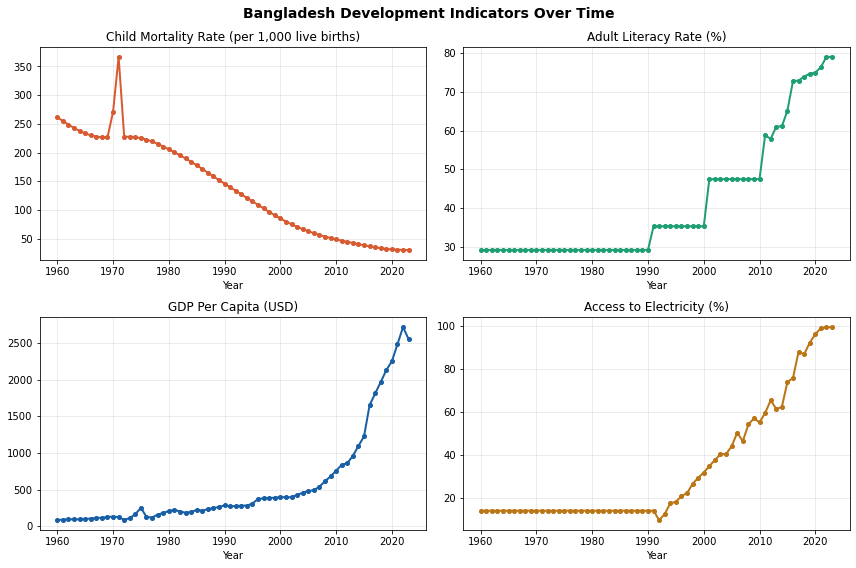

Plot saved.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Bangladesh Development Indicators Over Time',
             fontsize=14, fontweight='bold')

axes[0,0].plot(df_model['Year'], df_model['child_mortality'],
               color='#D85A30', linewidth=2, marker='o', markersize=4)
axes[0,0].set_title('Child Mortality Rate (per 1,000 live births)')
axes[0,0].set_xlabel('Year')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(df_model['Year'], df_model['literacy_rate'],
               color='#1D9E75', linewidth=2, marker='o', markersize=4)
axes[0,1].set_title('Adult Literacy Rate (%)')
axes[0,1].set_xlabel('Year')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(df_model['Year'], df_model['gdp_per_capita'],
               color='#185FA5', linewidth=2, marker='o', markersize=4)
axes[1,0].set_title('GDP Per Capita (USD)')
axes[1,0].set_xlabel('Year')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(df_model['Year'], df_model['electricity_access'],
               color='#BA7517', linewidth=2, marker='o', markersize=4)
axes[1,1].set_title('Access to Electricity (%)')
axes[1,1].set_xlabel('Year')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

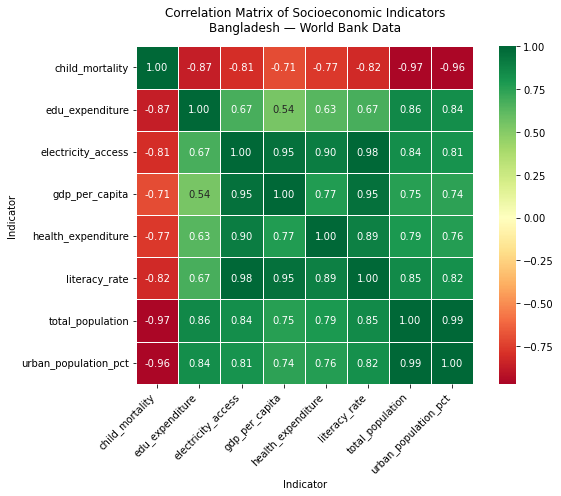


Correlation with child mortality:
Indicator
total_population       -0.971412
urban_population_pct   -0.964741
edu_expenditure        -0.866878
literacy_rate          -0.821472
electricity_access     -0.808710
health_expenditure     -0.771030
gdp_per_capita         -0.707926
child_mortality         1.000000
Name: child_mortality, dtype: float64


In [7]:
plt.figure(figsize=(9, 7))

corr_matrix = df_model.drop(columns=['Year']).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Socioeconomic Indicators\nBangladesh — World Bank Data',
          fontsize=12, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation with child mortality:")
print(corr_matrix['child_mortality'].sort_values())

## 3. Predictive Modelling

Two models are compared:
- **Linear Regression** — classical econometric baseline widely 
  used in development economics research
- **Random Forest** — machine learning ensemble that captures 
  non-linear relationships between indicators

**Target variable:** `child_mortality` (deaths per 1,000 live births)  
**Features:** literacy rate, electricity access, urban population, 
GDP per capita, health expenditure, education expenditure, 
total population

In [8]:
# Define features and target
feature_cols = [col for col in df_model.columns
                if col not in ['Year', 'child_mortality']]

X = df_model[feature_cols]
y = df_model['child_mortality']

print("Features used:")
for f in feature_cols:
    print(f"  - {f}")
print(f"\nSample size: {len(X)} observations")
print(f"\nTarget variable stats:")
print(y.describe())

Features used:
  - edu_expenditure
  - electricity_access
  - gdp_per_capita
  - health_expenditure
  - literacy_rate
  - total_population
  - urban_population_pct

Sample size: 64 observations

Target variable stats:
count     64.000000
mean     140.257813
std       84.709990
min       30.600000
25%       56.000000
50%      136.750000
75%      223.400000
max      366.700000
Name: child_mortality, dtype: float64


In [9]:
# Spliting into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

# Scale features, required for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nFeature scaling applied for Linear Regression.")

Training samples: 51
Test samples:     13

Feature scaling applied for Linear Regression.


In [10]:
# Model 1: Linear Regression 
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_rmse  = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2    = r2_score(y_test, lr_preds)

# Model 2: Random Forest 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2    = r2_score(y_test, rf_preds)

# Print comparison
print("=" * 45)
print(f"{'Model':<25} {'RMSE':>8}  {'R²':>8}")
print("=" * 45)
print(f"{'Linear Regression':<25} {lr_rmse:>8.3f}  {lr_r2:>8.3f}")
print(f"{'Random Forest':<25} {rf_rmse:>8.3f}  {rf_r2:>8.3f}")
print("=" * 45)

Model                         RMSE        R²
Linear Regression           13.598     0.976
Random Forest               26.539     0.907


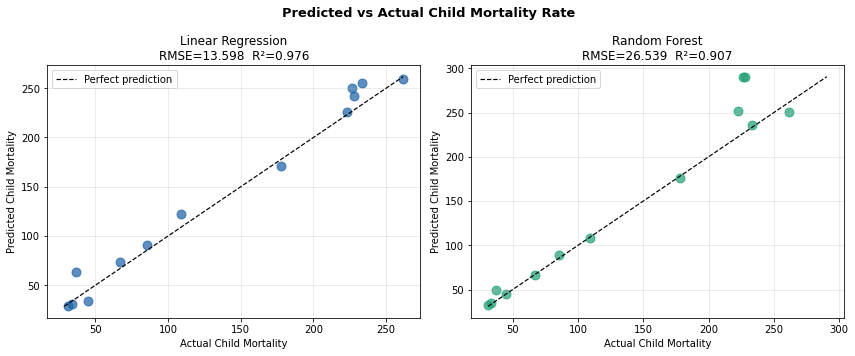

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Predicted vs Actual Child Mortality Rate',
             fontsize=13, fontweight='bold')

for ax, preds, title, color in zip(
    axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest'],
    ['#185FA5', '#1D9E75']
):
    ax.scatter(y_test, preds, color=color, alpha=0.7, s=80)
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'k--', linewidth=1.2, label='Perfect prediction')
    ax.set_xlabel('Actual Child Mortality')
    ax.set_ylabel('Predicted Child Mortality')
    ax.set_title(
        f'{title}\n'
        f'RMSE={np.sqrt(mean_squared_error(y_test,preds)):.3f}  '
        f'R²={r2_score(y_test,preds):.3f}'
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

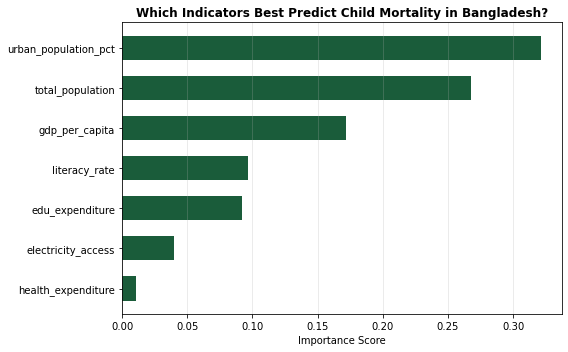


Feature importance ranking:
             Feature  Importance
urban_population_pct    0.321145
    total_population    0.267778
      gdp_per_capita    0.171893
       literacy_rate    0.096821
     edu_expenditure    0.091688
  electricity_access    0.040125
  health_expenditure    0.010549


In [12]:
importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='#1A5C3A', height=0.6)
plt.xlabel('Importance Score')
plt.title(
    'Which Indicators Best Predict Child Mortality in Bangladesh?',
    fontweight='bold'
)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature importance ranking:")
print(importance_df.sort_values(
    'Importance', ascending=False).to_string(index=False))

## 4. Conclusions

### Model performance
- **Linear Regression** achieved R²=0.976 and RMSE=13.598, 
  outperforming Random Forest (R²=0.907, RMSE=26.539)
- This result makes intuitive sense: child mortality in Bangladesh 
  has followed a consistent downward trend over decades, a pattern 
  that linear models capture effectively
- The high R² values across both models confirm that socioeconomic 
  indicators are strong predictors of child welfare outcomes

### Key findings
- **Urban population percentage** and **total population** are the 
  strongest predictors of child mortality in this dataset, followed 
  by **GDP per capita** and **literacy rate**
- All features are negatively correlated with child mortality, as 
  development indicators improve, child mortality declines
- This is consistent with development economics literature linking 
  urbanisation, income growth, and education access to improved 
  child health outcomes in South Asia

### Limitations and next steps
- This model uses national-level annual data. District or upazila-level 
  disaggregation using HIES microdata or satellite covariates would 
  produce more policy-relevant predictions, an approach explored in 
  Small Area Estimation literature
- Future work could incorporate remotely sensed data such as nighttime 
  lights or vegetation indices as additional covariates. 